In [ ]:
import import_helper
import_helper.add_models()

import model.conditions as ic
import model.nondim_kondo_model as nondim_kondo
import model.mesh_generation as meshgen
import model.intensity_analysis as analyse
import model.mutual_inhibition_grn as grn 

from tqdm import tqdm
from fenics import *
from mshr import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['image.cmap'] = 'magma'
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.style.use('seaborn-v0_8-bright')
plt.rcParams["font.family"] = "monospace"

In [2]:
# insert parameters for dimensionless model
Amax_nd = 2 #0.06 / 0.03 # max for production term
Imax_nd = 5 #0.17 / 0.03 # max for production term

delta = 20
aA = 8/3 #0.08 / 0.03
bA = -8/3 #-0.08 / 0.03
cA_nd = 1/18
dA = 1 #0.03 * 100

aI = 10/3 #0.1 / 0.03
bI = 0
cI_nd = -1/6
dI = 2 
kappa = 2

radius = 250
const_prop = 0.8593 # 2.5
intercept = 5.765
gamma = const_prop * (radius/100)**2 + intercept #31.85 #65 #160 #28.9  #84 #235.6 #150.8 #28.9 
print(gamma)

## square
Aeq_nd, Ieq_nd = nondim_kondo.fixed_points(**{"aA":aA, "bA":bA, "cA":cA_nd, "dA":dA,
                                              "aI":aI, "bI":bI, "cI":cI_nd, "dI":dI})
print(Aeq_nd, Ieq_nd)
TI = nondim_kondo.check_Turing_instability(**{"delta":delta, "aA":aA, "bA":bA, "cA":cA_nd, "dA":dA,
                                              "aI":aI, "bI":bI, "cI":cI_nd, "dI":dI})
print(TI)
non_dim_param = {"delta":delta, "gamma":gamma, "kappa":kappa,
                 "Amax_nd":Amax_nd, "Imax_nd":Imax_nd, 
                 "aA":aA, "bA":bA, "cA_nd":cA_nd, "dA":dA,
                 "aI":aI, "bI":bI, "cI_nd":cI_nd}

11.135625
0.09999999999999999 0.08333333333333331
(True, True)


In [3]:
u0 = ic.InitialConditionsRandom(noise=0.001, Ac=Aeq_nd, Ic=Ieq_nd)

# wavy stars
wavy_star_length = 0.85 # to obtain area=pi
min_dist = wavy_star_length
mesh, vertices = meshgen.wavy_star(octagon_length=wavy_star_length, return_vertices=True)

# star_length = np.sqrt(np.pi)/2
# min_dist = (star_length/2)*np.sqrt(2)
# mesh, vertices = meshgen.four_pointed_star(length=star_length,
#                                            res=30,
#                                            return_vertices=True)

print(list(vertices))

[(1.3599999999999999, -4.163336342344337e-17), (1.3464527637987742, 0.04798967626028416), (1.308857436279733, 0.0956883002145814), (1.2517835890698303, 0.14280481955690463), (1.1798007937960193, 0.1890481819812669), (1.0974786220852528, 0.23412733518168136), (1.0093866455644847, 0.2777512268521607), (0.9200944358606683, 0.3196288046867184), (0.8341664609504812, 0.35947177191776597), (0.7549286538220794, 0.3976605356534059), (0.6828624559464634, 0.43611128723029835), (0.6180515301609232, 0.47695498471878006), (0.560579539302749, 0.5223225861891879), (0.5104400330538089, 0.5742549365564376), (0.4664031848979768, 0.6335695045374495), (0.4263575012064865, 0.7002020917365045), (0.3881720239090013, 0.774069035316313), (0.34971588345499277, 0.85508650848827), (0.30933904407318064, 0.9422801116991845), (0.2669976016259563, 1.031700660447266), (0.22298260841930678, 1.1187785831055608), (0.17758511675921926, 1.1989443080471152), (0.13109617895168033, 1.2676282636449758), (0.08380684730267726, 1.

In [4]:
Tend = 1
rd_steady_state = nondim_kondo.dimensionless_kondo(mesh, 
                                                   u0,
                                                   T=Tend, 
                                                   dt=0.1,
                                                   param_set=non_dim_param,
                                                   boundary_conditions="Mixed")
                                                #    save_file=f"paraview_files/circle_Aeq1.4_gamma196",
                                                #    save_step=0.01,
                                                #    check_production=True)
A, I  = split(rd_steady_state)

100%|██████████| 10/10 [00:02<00:00,  3.45it/s]


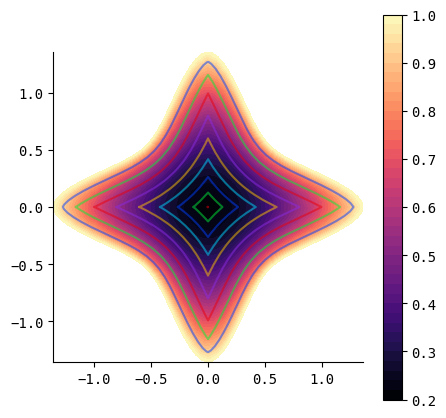

In [5]:
distances = np.linspace(0, min_dist, 11)

fig, ax = plt.subplots(figsize=(5,5))
im = plot(A)
# ax.axis("off")
fig.colorbar(im)
intensities_R350 = analyse.intensities_from_contours(distances,
                                                     vertices,
                                                     A,
                                                     mesh,
                                                     plot=True,
                                                     axes=ax)
# fig.savefig("rd_model_triangle_R350.png", transparent=True)

In [6]:
def solve_grn_for_2D_space(activator_profile,
                           mesh,
                           x_range, 
                           y_range,
                           n_space,
                           U,
                           time_array,
                           params):
    
    x_space, y_space = np.linspace(*x_range, n_space), np.linspace(*y_range, n_space)
    # print(x_space)
    # print(y_space)
    X, Y = np.meshgrid(x_space, y_space)
    T_results_2D = np.zeros((n_space, n_space, len(time_array)))
    S_results_2D = np.zeros((n_space, n_space, len(time_array)))

    for i in tqdm(range(n_space)):
        for j in range(n_space):
            coordinate = (x_space[i], y_space[j])
            # print(coordinate)
            A_value = analyse.evaluate_point(coordinate, activator_profile, mesh)
            if A_value is not None: 
                T_results_2D[i, j, :], S_results_2D[i, j, :] = grn.solve_grn(U,
                                                                             time_array,
                                                                             A_value,
                                                                             *params)
            else:
                T_results_2D[i, j, :], S_results_2D[i, j, :] = None, None
                
    return T_results_2D, S_results_2D
    
def obtain_limits_from_vertices(vertices):
    vertices_array = np.vstack(vertices)
    xmax, xmin = np.max(vertices_array[:,0]), np.min(vertices_array[:,0])
    ymax, ymin = np.max(vertices_array[:,1]), np.min(vertices_array[:,1])
    return (xmin, xmax), (ymin, ymax)


In [7]:
x_range, y_range = obtain_limits_from_vertices(vertices)
n_space = 100
U = (0, 0.2)
t_end = 10
time_array = np.linspace(0, t_end, 100)
alpha0 = 2 #0.2
beta0 = 1  #0.1
S0 =  1.003
T0 = 0.06
S1 = 0.186
params = (alpha0, beta0, S0, T0, S1)
T_results, S_results = solve_grn_for_2D_space(A,
                                              mesh,
                                              x_range,
                                              y_range,
                                              n_space,
                                              U,
                                              time_array,
                                              params)


100%|██████████| 100/100 [01:02<00:00,  1.59it/s]


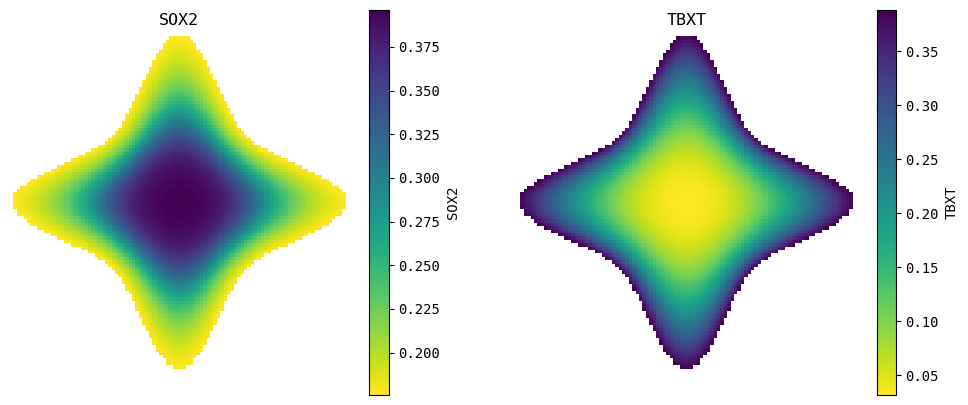

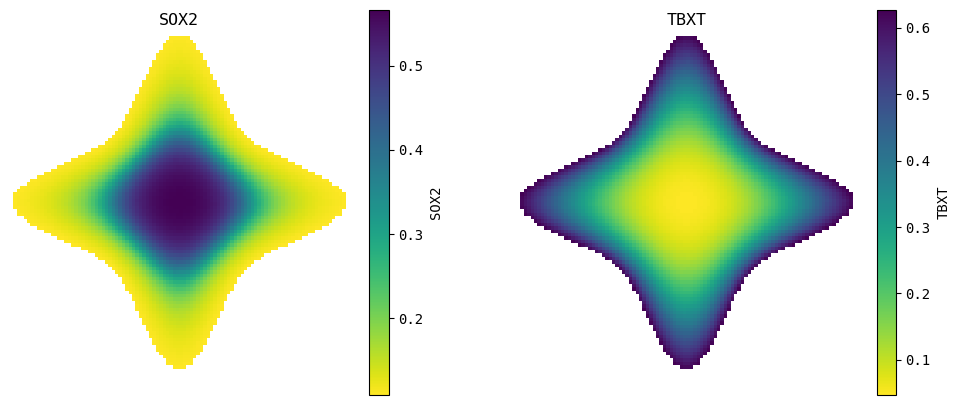

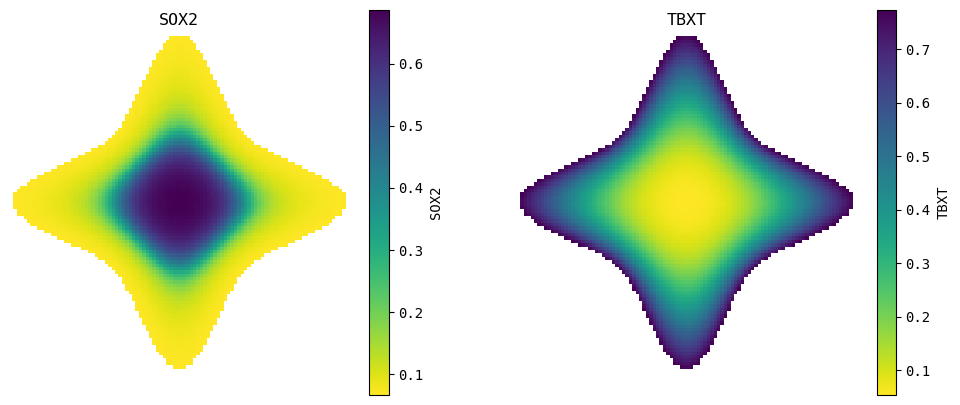

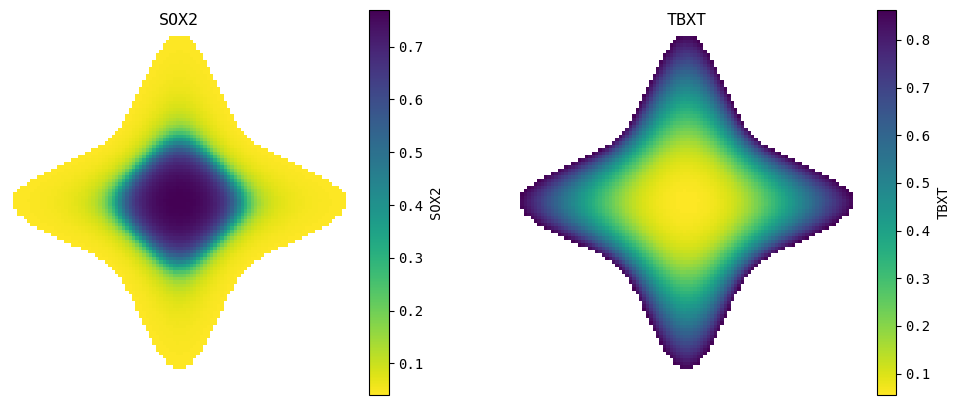

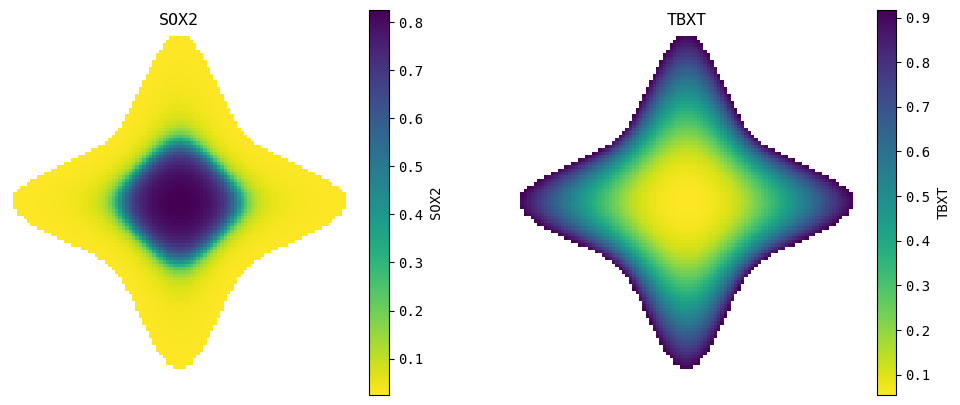

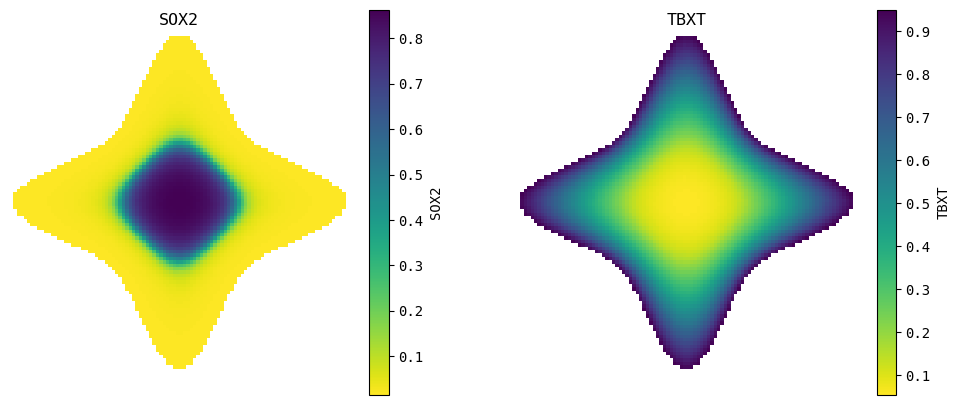

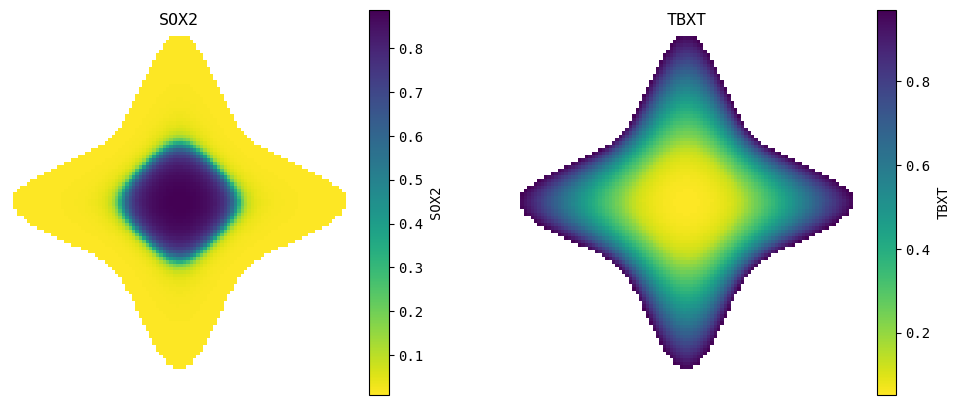

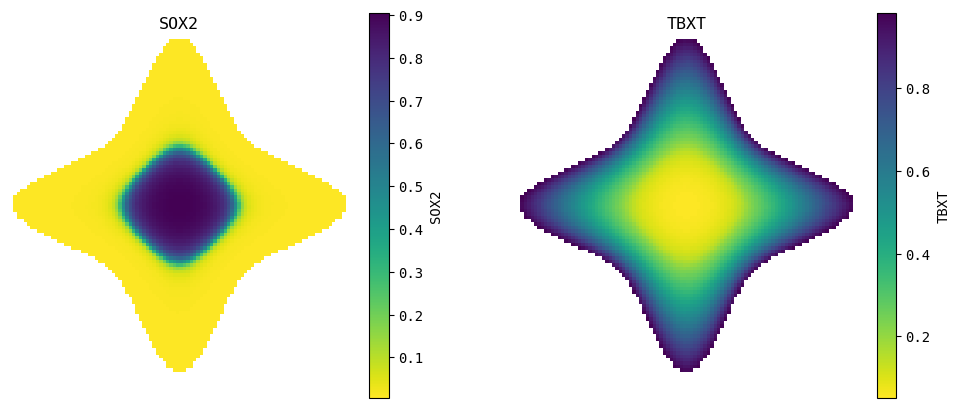

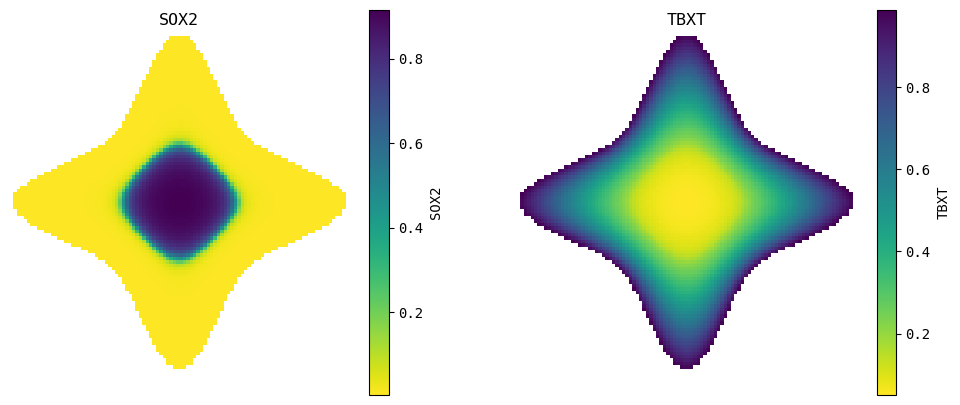

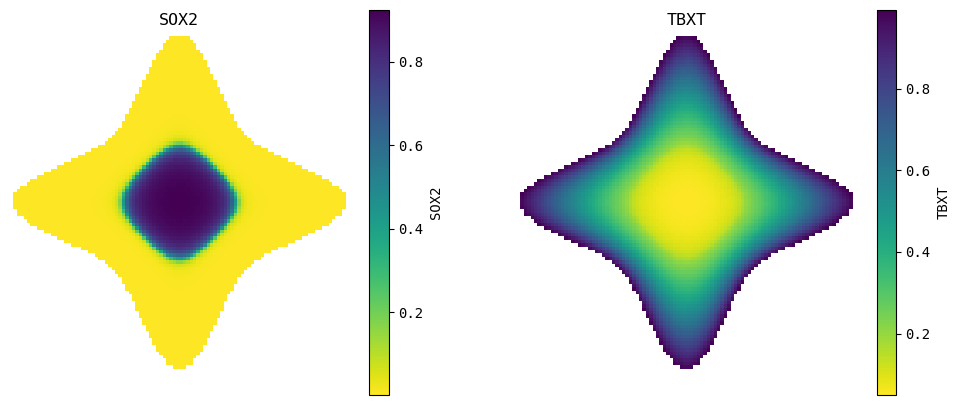

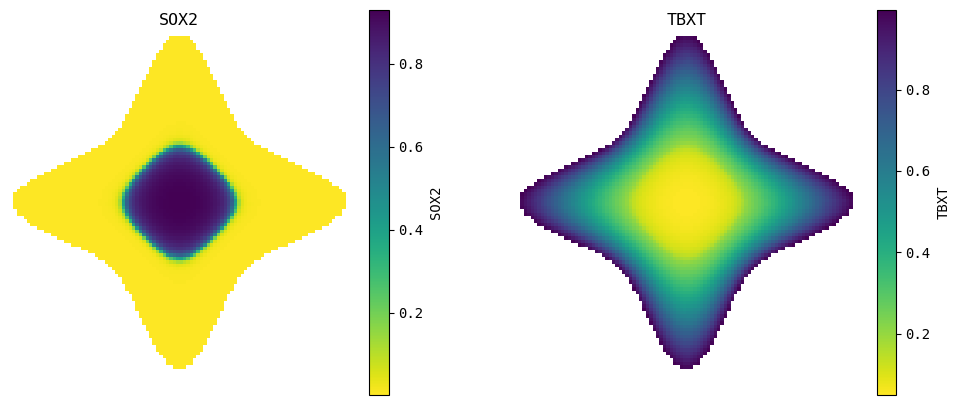

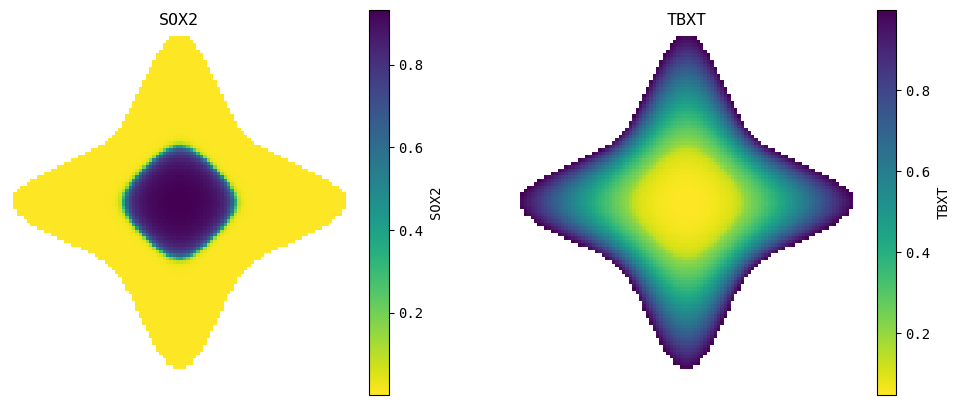

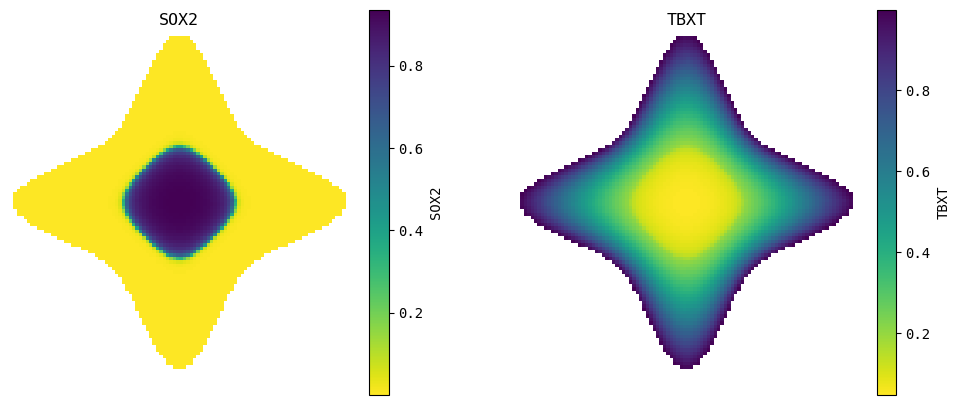

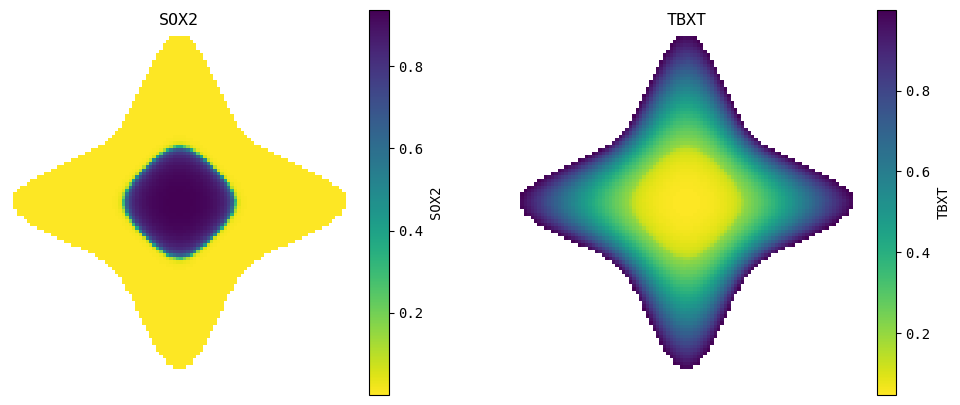

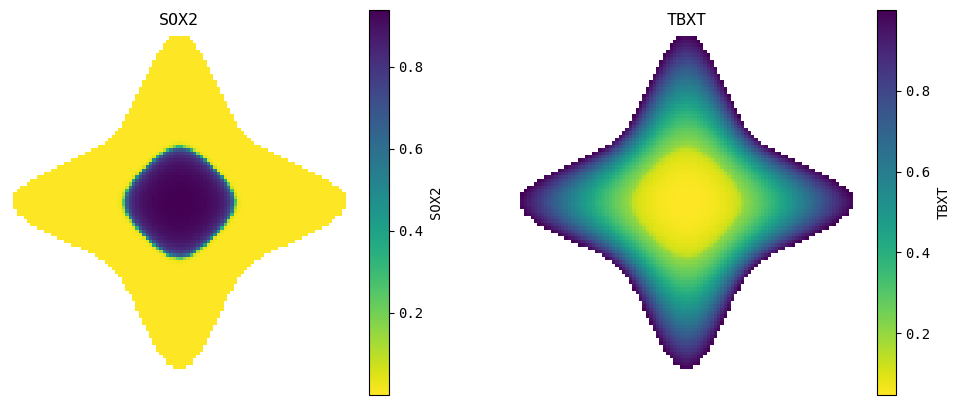

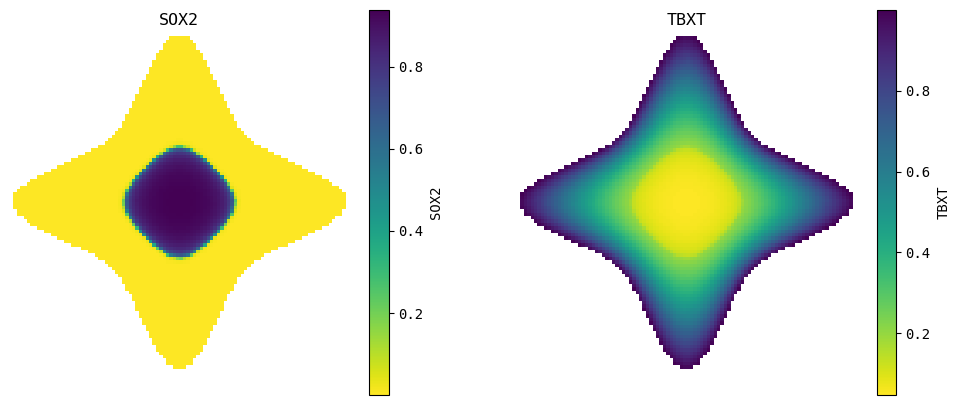

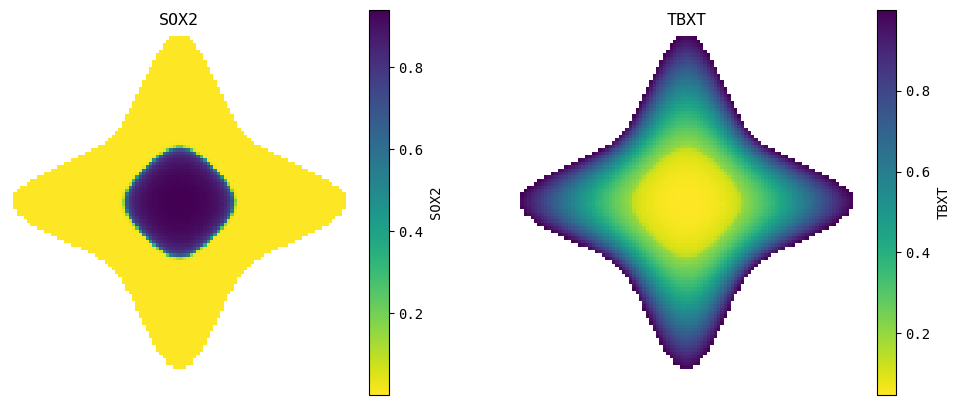

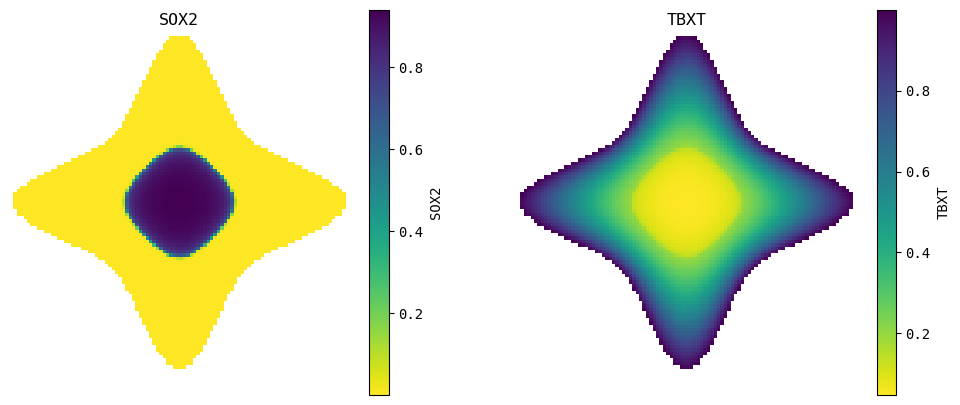

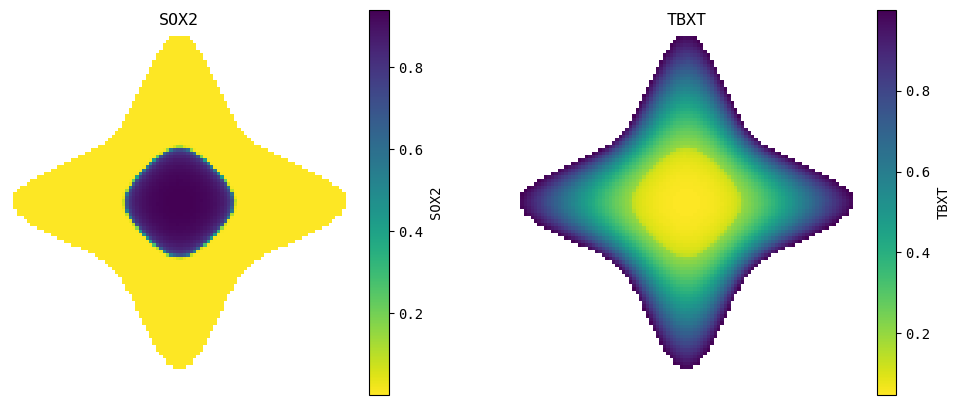

In [8]:
# save all figures
time_to_save = np.arange(5, len(time_array), 5)
shape = "waves"
for i in range(len(time_to_save)):
    fig, ax = plt.subplots(1,2,figsize=(12, 5))
    im = ax[0].imshow(S_results[:,:,time_to_save[i]], cmap="viridis_r")
    ax[0].set_title("SOX2")
    im1 = ax[1].imshow(T_results[:,:,time_to_save[i]], cmap="viridis_r")
    ax[1].set_title("TBXT")
    ax[0].axis("off")
    ax[1].axis("off")
    fig.colorbar(im, label="SOX2")
    fig.colorbar(im1, label="TBXT")
    fig.savefig(f"figures/{shape}/{radius}um_time_{time_to_save[i]}.png",
                transparent=True)

In [9]:
# fig, ax = plt.subplots(1,2,figsize=(12, 5))
# # binary = T_results[:,:,-1]>0
# time_step = len(time_array)-1
# im = ax[0].imshow(S_results[:,:,time_step])
# ax[0].set_title("SOX2")
# im1 = ax[1].imshow(T_results[:,:,time_step])
# ax[1].set_title("TBXT")
# ax[0].axis("off")
# ax[1].axis("off")
# fig.colorbar(im, label="SOX2")
# fig.colorbar(im1, label="TBXT")
# fig.savefig(f"figures/star/{radius}um_time_{time_step}.png")
